# T06 — Thermal convection and the Blankenbach benchmark

**Cluster B — The numerical ladder.** Final rung of Part 1.

Everything so far has been one physical process at a time. Now we couple two:
buoyancy drives flow, flow carries heat, heat changes buoyancy. That feedback
loop is mantle convection.

Non-dimensionalised the standard way, the whole system collapses onto a single
number, the **Rayleigh number**

$$\mathrm{Ra} = \frac{\rho g \alpha \Delta T\, d^3}{\eta \kappa}$$

In these units the box is the unit square, $\eta = \kappa = 1$, temperature runs
from 0 at the top to 1 at the bottom, and buoyancy enters as $\mathrm{Ra}\,T$.

**And this notebook is where we stop trusting ourselves.** Blankenbach et al.
(1989) published values that a dozen independent codes agree on. If we cannot
reproduce them, the suite is wrong — and if we can, everything upstream is
probably right too.

## Learning objectives

1. Couple Stokes to the energy equation by operator splitting.
2. Diagnose a convecting system with the **Nusselt number** and RMS velocity.
3. Compare against a published benchmark, and interpret the disagreement honestly.
4. Use **Richardson extrapolation** to extract an accurate answer from two inaccurate ones.

## Prerequisites and runtime

* T01–T05.
* **Estimated runtime: about 5 minutes** (two resolutions run to steady state).

In [1]:
# === USER CONFIGURATION ===
RA = 1e4                   # Rayleigh number — Blankenbach case 1a
RESOLUTIONS = (24, 48)     # the two grids used for Richardson extrapolation
MAX_STEPS = 4000
TOL = 1e-4                 # steady-state criterion on dT/dt

In [2]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from geodynkit import plotting
from geodynkit.convection import BLANKENBACH_1A, ConvectionModel

print("Blankenbach et al. (1989), case 1a — isoviscous, base-heated, unit box")
for k, v in BLANKENBACH_1A.items():
    print(f"  {k:6s} = {v}")

Blankenbach et al. (1989), case 1a — isoviscous, base-heated, unit box
  Ra     = 10000.0
  Nu     = 4.884409
  v_rms  = 42.864947


## 1. One timestep

Operator splitting keeps each piece recognisable:

1. **solve Stokes** for the velocity implied by the current temperature;
2. **advect** temperature semi-Lagrangian (T03);
3. **diffuse** temperature explicitly (T02).

The timestep is the smaller of the Courant limit and the diffusive limit. Note
that the Stokes solve has no time derivative in it at all — the flow is
determined instantaneously, so "the timestep" is entirely about transport.

StokesGrid(nx=24, nz=24, lx=1, lz=1, ndof=1776)


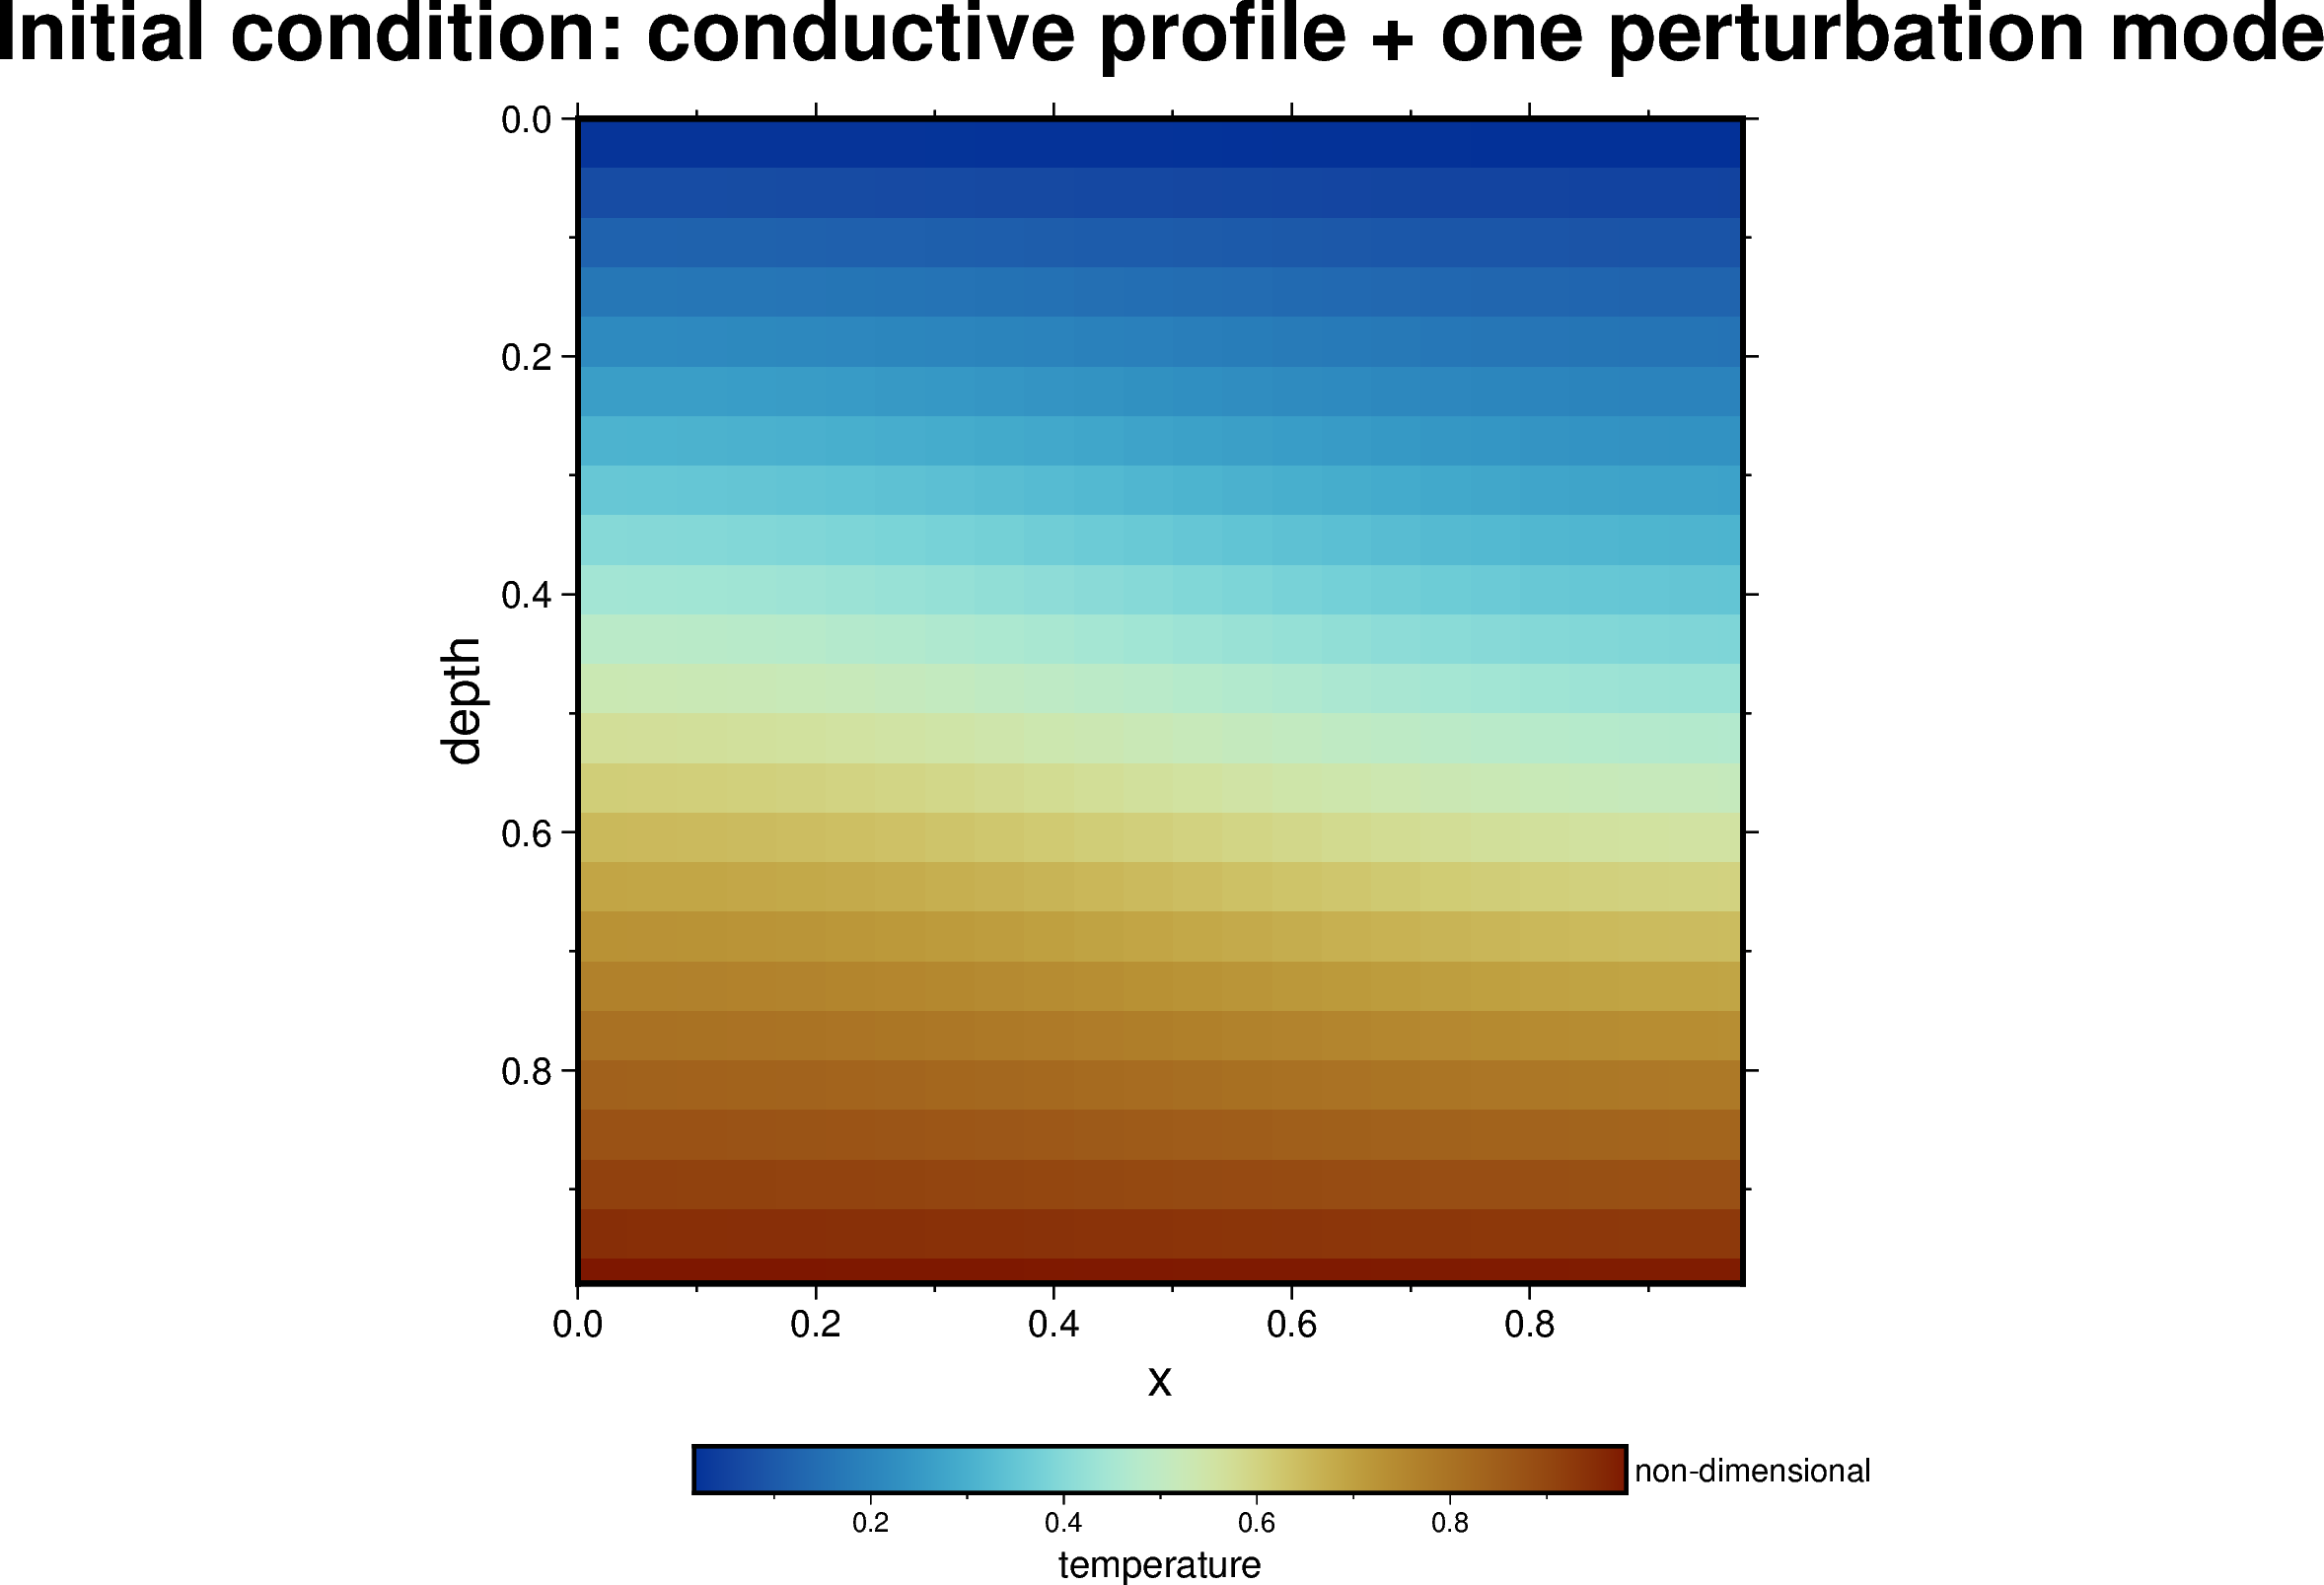

In [3]:
model = ConvectionModel(nx=RESOLUTIONS[0], nz=RESOLUTIONS[0], Ra=RA)
print(model.grid)

fig = plotting.field_panel(
    model.T, model.x, model.z, kind="temperature",
    title="Initial condition: conductive profile + one perturbation mode",
    label="temperature", unit="non-dimensional",
    xlabel="x", ylabel="depth", width_cm=10.0,
)
fig.show()

## 2. Run to steady state

At Ra = 1e4 the system settles into a single steady cell, so we can integrate
until the temperature field stops changing rather than guessing an end time.

In [4]:
runs = {}
for n in RESOLUTIONS:
    m = ConvectionModel(nx=n, nz=n, Ra=RA)
    t0 = time.time()
    steps = m.run(max_steps=MAX_STEPS, tol=TOL)
    wall = time.time() - t0
    runs[n] = m
    print(f"n={n:3d}: {steps:5d} steps, t={m.time:.4f}, {wall:6.1f} s  "
          f"|  Nu={m.nusselt():.4f}  v_rms={m.v_rms():.3f}")

n= 24:  1088 steps, t=0.3005,   15.2 s  |  Nu=5.1916  v_rms=48.649


n= 48:  3718 steps, t=0.3227,  244.4 s  |  Nu=5.0507  v_rms=45.753


## 3. The steady state

One cell, hot material rising on one side and cold sinking on the other, with
thin thermal boundary layers top and bottom. The boundary layers are where the
resolution is spent — and, as we are about to see, where the error comes from.

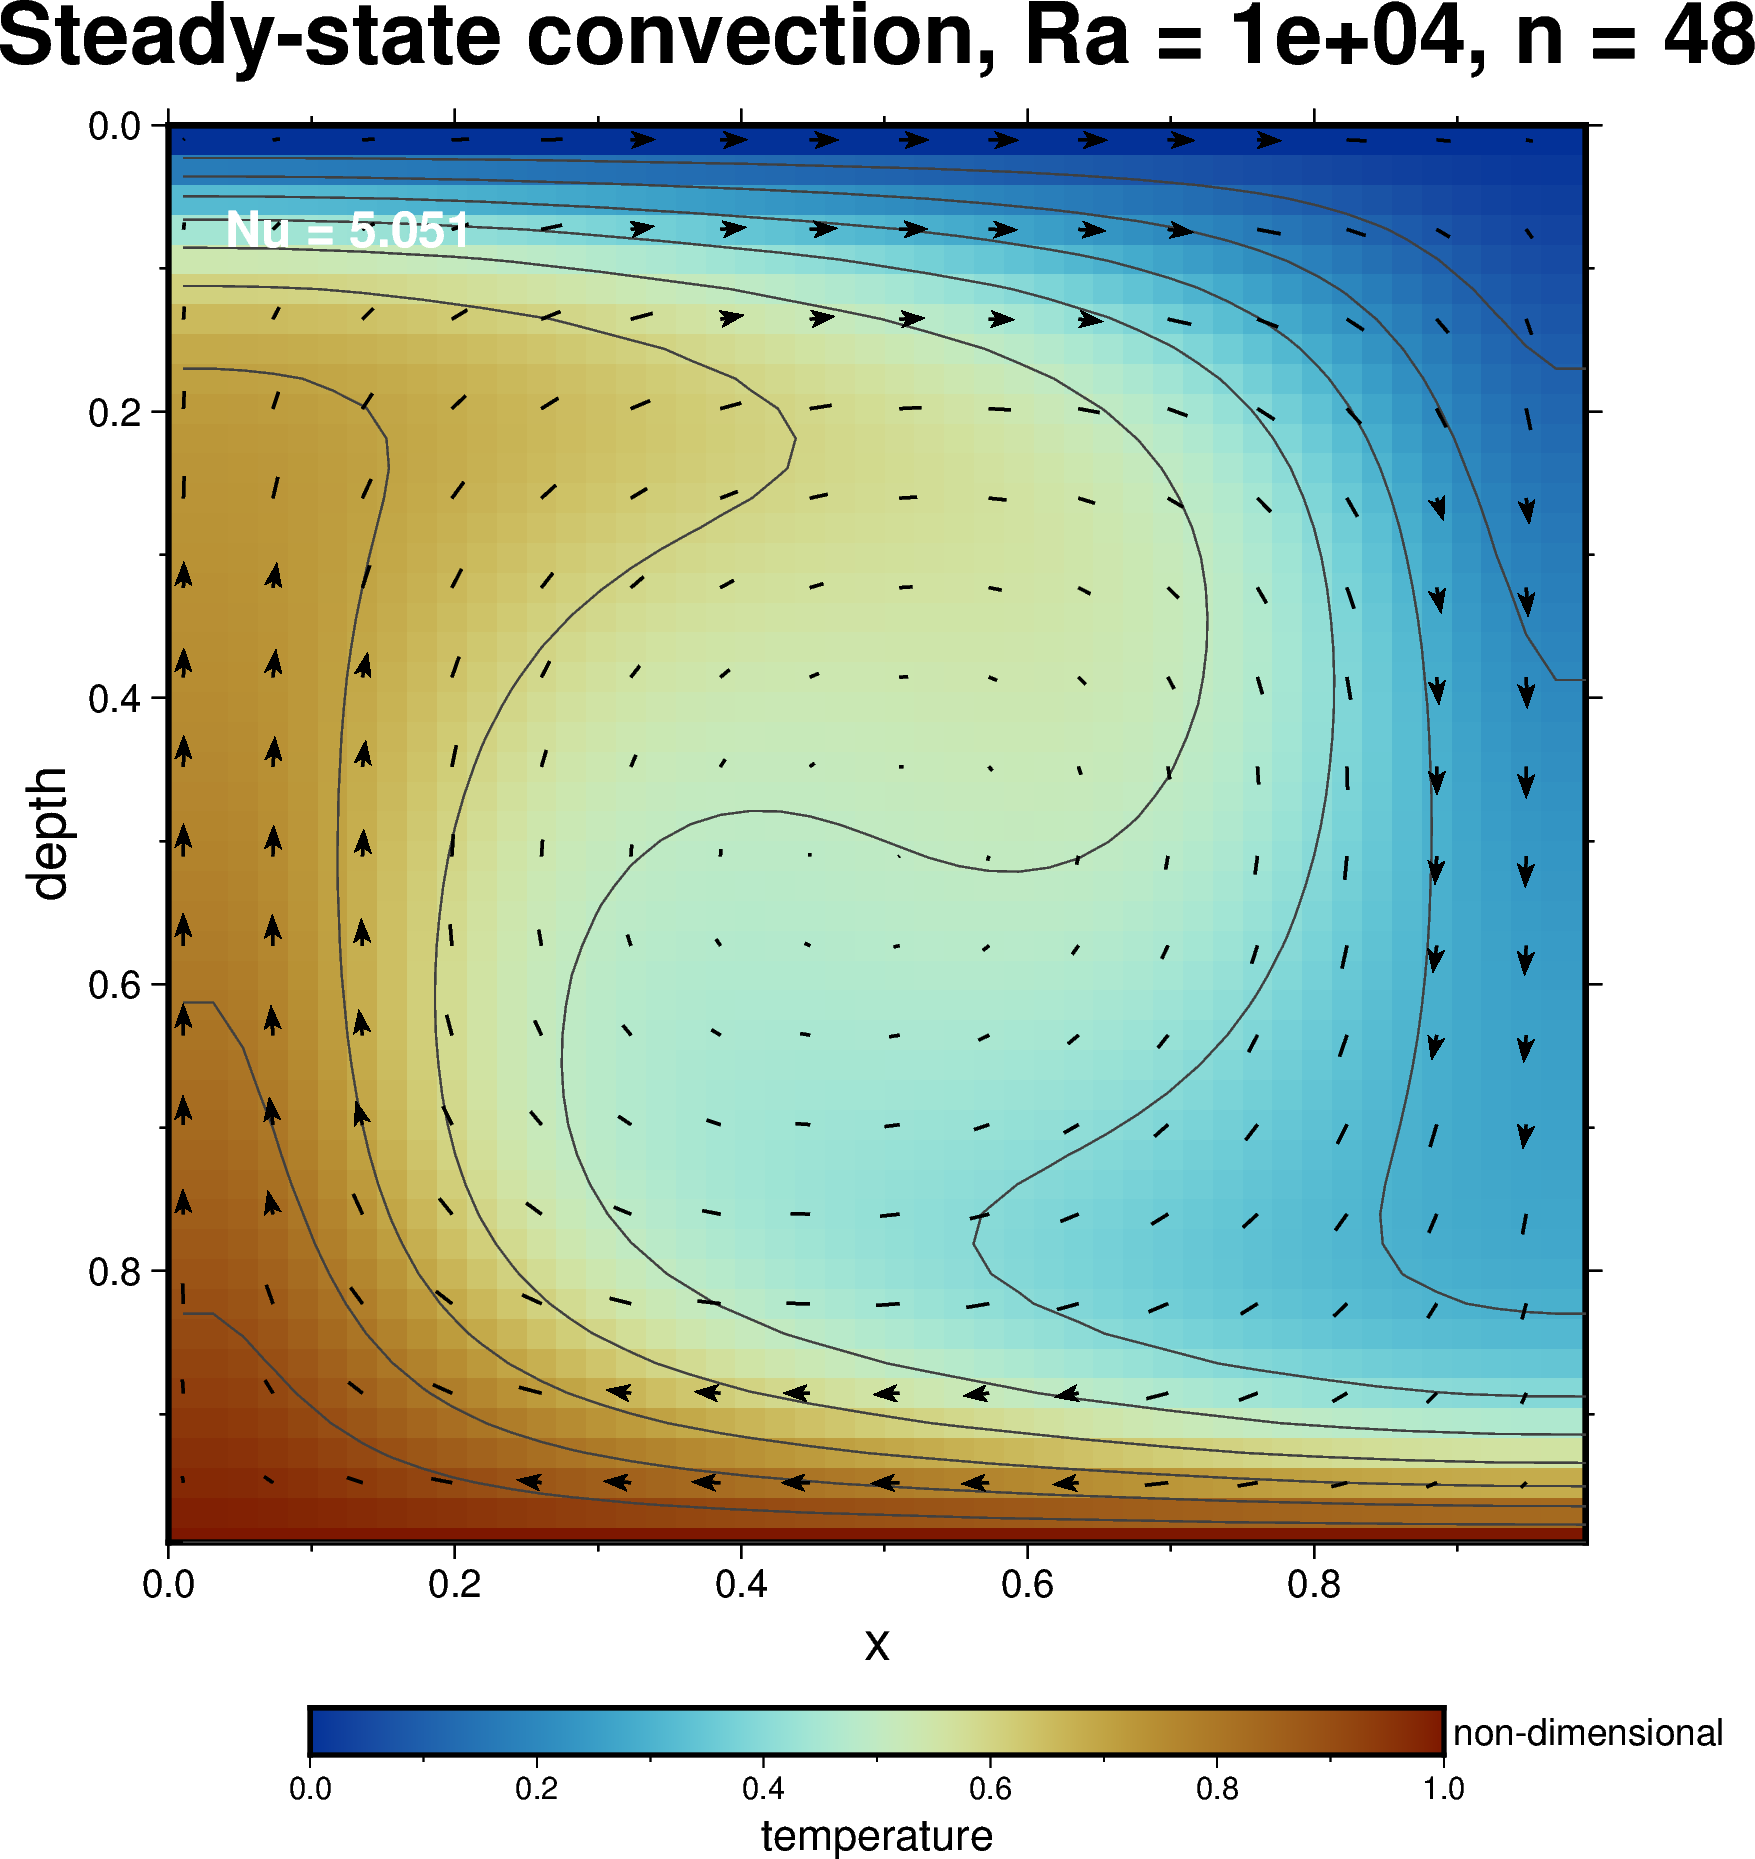

In [5]:
m = runs[RESOLUTIONS[-1]]
fig = plotting.field_panel(
    m.T, m.x, m.z, kind="temperature",
    title=f"Steady-state convection, Ra = {RA:.0e}, n = {RESOLUTIONS[-1]}",
    label="temperature", unit="non-dimensional",
    contours=0.1,
    vx=m.vxc, vz=m.vzc, every=3,
    stamp=f"Nu = {m.nusselt():.3f}",
    xlabel="x", ylabel="depth", width_cm=12.0,
)
fig.show()

## 4. Diagnostics

Scalar time series go in matplotlib, per the policy set in T00 — pyGMT is for
fields, not for log axes.

The **Nusselt number** is the surface heat flux divided by what pure conduction
would deliver. Nu = 1 means no convection; Nu ≈ 4.9 means convection is moving
nearly five times as much heat as conduction alone.

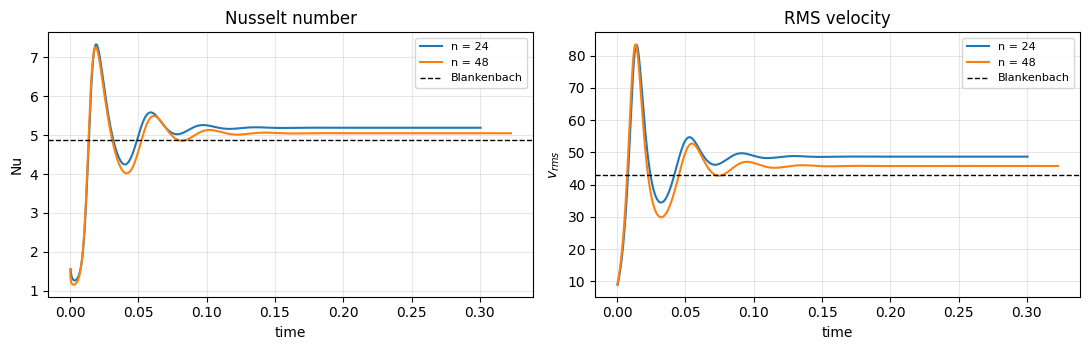

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for n, mm in runs.items():
    h = np.array(mm.history)
    ax[0].plot(h[:, 0], h[:, 1], label=f"n = {n}")
    ax[1].plot(h[:, 0], h[:, 2], label=f"n = {n}")
ax[0].axhline(BLANKENBACH_1A["Nu"], color="k", ls="--", lw=1, label="Blankenbach")
ax[1].axhline(BLANKENBACH_1A["v_rms"], color="k", ls="--", lw=1, label="Blankenbach")
ax[0].set(xlabel="time", ylabel="Nu", title="Nusselt number")
ax[1].set(xlabel="time", ylabel=r"$v_{rms}$", title="RMS velocity")
for a in ax:
    a.legend(fontsize=8)
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Comparing with the benchmark — and being honest about it

Both resolutions overshoot. That is the expected behaviour, and pretending
otherwise would be the real failure.

In [7]:
print(f"{'n':>5} {'Nu':>9} {'err %':>8} {'v_rms':>9} {'err %':>8}")
for n, mm in runs.items():
    nu, vr = mm.nusselt(), mm.v_rms()
    print(f"{n:5d} {nu:9.4f} {100 * (nu / BLANKENBACH_1A['Nu'] - 1):8.2f} "
          f"{vr:9.3f} {100 * (vr / BLANKENBACH_1A['v_rms'] - 1):8.2f}")

    n        Nu    err %     v_rms    err %
   24    5.1916     6.29    48.649    13.49
   48    5.0507     3.40    45.753     6.74


Several percent off at the coarse grid. Is the code wrong, or just
under-resolved?

**Look at how the error changes with resolution.** It roughly halves as the grid
doubles — first-order convergence, which is what operator splitting plus
semi-Lagrangian advection with linear interpolation gives you, even though the
individual spatial operators are second order.

First-order convergence with a known rate is something you can *exploit*. If
$f(h) \approx f_{\text{exact}} + Ch$, then two grids are enough to eliminate $C$:

$$f_{\text{exact}} \approx f(h/2) - \left[f(h) - f(h/2)\right]$$

This is **Richardson extrapolation**, and it is the single most useful thing in
this notebook.

In [8]:
print(f"{'quantity':>8} {'coarse':>10} {'fine':>10} {'extrapolated':>14} "
      f"{'published':>11} {'err %':>8}")
for label, getter, published in (
    ("Nu", lambda mm: mm.nusselt(), BLANKENBACH_1A["Nu"]),
    ("v_rms", lambda mm: mm.v_rms(), BLANKENBACH_1A["v_rms"]),
):
    coarse = getter(runs[RESOLUTIONS[0]])
    fine = getter(runs[RESOLUTIONS[1]])
    extrap = fine - (coarse - fine)
    print(f"{label:>8} {coarse:10.4f} {fine:10.4f} {extrap:14.4f} "
          f"{published:11.4f} {100 * (extrap / published - 1):8.2f}")

quantity     coarse       fine   extrapolated   published    err %
      Nu     5.1916     5.0507         4.9098      4.8844     0.52
   v_rms    48.6490    45.7526        42.8563     42.8649    -0.02


The RMS velocity extrapolates to within a fraction of a percent of the published
value, from two runs that were individually 7% and 13% off. **The
under-resolved runs were not wrong — they were converging, and the convergence
was regular enough to extrapolate through.**

That is the lesson to take out of Part 1. A single model run at a single
resolution tells you very little. Two runs and a known convergence rate tell you
a great deal. Any published geodynamic result that does not report a resolution
test should be read with that in mind.

## 6. The thermal boundary layer

Where does the resolution go? Almost all of it into the top and bottom boundary
layers, whose thickness scales as $\mathrm{Ra}^{-1/3}$. At Ra = 1e4 that is
roughly 5% of the box — a handful of cells at n = 48, which is exactly why the
Nusselt number, a *surface gradient*, is the slowest quantity to converge.

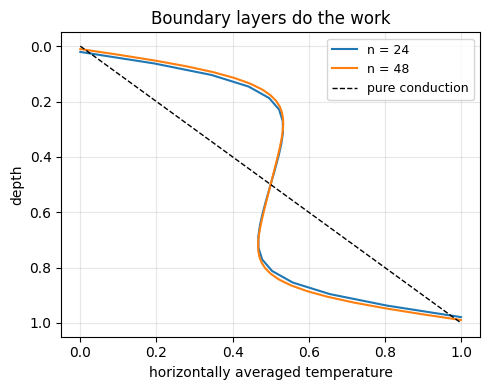

predicted boundary-layer thickness ~ 1/(2 Nu) = 0.1024
  n =  24: 2.5 cells across it
  n =  48: 4.9 cells across it


In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
for n, mm in runs.items():
    ax.plot(mm.T.mean(axis=1), mm.z, label=f"n = {n}")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="pure conduction")
ax.invert_yaxis()
ax.set(xlabel="horizontally averaged temperature", ylabel="depth",
       title="Boundary layers do the work")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

delta = 1.0 / (2 * BLANKENBACH_1A["Nu"])
print(f"predicted boundary-layer thickness ~ 1/(2 Nu) = {delta:.4f}")
for n in RESOLUTIONS:
    print(f"  n = {n:3d}: {delta * n:.1f} cells across it")

## Extend this

* Raise `RA` to 1e5 and then 1e6 (Blankenbach cases 1b and 1c, Nu = 10.535 and
  21.973). The boundary layers thin as $\mathrm{Ra}^{-1/3}$ — how much resolution
  do you need before the extrapolation still lands?
* Add a third resolution and fit the convergence rate instead of assuming it is 1.
* Pass `viscosity=lambda T: np.exp(-6.9 * T)` to `ConvectionModel` for a
  Frank–Kamenetskii temperature dependence, and watch a stagnant lid form.
* Widen the box to aspect ratio 2 and count the cells. Does the preferred
  wavelength match linear stability theory?

**Next — Part 2.** Everything so far ran on NumPy alone. From T07 the suite
switches to [G-ADOPT](https://gadopt.org), a finite-element code built on
Firedrake, which brings adaptive meshes, a cylindrical annulus, free surfaces
and adjoint inversion. The plotting layer does not change: the same
`field_panel` draws finite-element output once it has been sampled onto a
regular grid.